In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

In [8]:
df = pd.read_csv('../../data/death_rate.csv')
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              850 non-null    int64  
 1   state             850 non-null    object 
 2   sex               850 non-null    object 
 3   age_group         850 non-null    object 
 4   age_group_detail  850 non-null    object 
 5   race              850 non-null    object 
 6   hydro_gms         850 non-null    float64
 7   oxy_gms           850 non-null    float64
 8   unempl_rate       850 non-null    float64
 9   poverty_rate      850 non-null    float64
 10  gsp               850 non-null    float64
 11  min_wage          850 non-null    float64
 12  snap_rate         850 non-null    float64
 13  medicaid_rate     850 non-null    float64
 14  aca_exp           850 non-null    float64
 15  gov_dem           850 non-null    int64  
 16  death_rate        850 non-null    float64
dt

,year,state,sex,age_group,age_group_detail,race,hydro_gms,oxy_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,aca_exp,gov_dem,death_rate
0,2000,AL,Both Sexes,All Ages,All Ages,All Races,10664.777495,6724.566122,4.6,13.3,120132.9,5.15,0.088958,0.126888,0.0,1,4.4857
1,2001,AL,Both Sexes,All Ages,All Ages,All Races,12065.615178,7317.474753,5.1,15.9,123035.3,5.15,0.092060,0.150865,0.0,1,4.8915
2,2002,AL,Both Sexes,All Ages,All Ages,All Races,13477.895908,7919.213212,5.9,14.5,128117.4,5.15,0.099004,0.164526,0.0,1,4.7619
3,2003,AL,Both Sexes,All Ages,All Ages,All Races,14846.170182,8496.910730,6.0,15.0,133969.3,5.15,0.104822,0.166062,0.0,0,4.4333
4,2004,AL,Both Sexes,All Ages,All Ages,All Races,16186.581541,9060.957298,5.7,16.9,146886.7,5.15,0.109826,0.172655,0.0,0,6.3542


In [9]:
# Drop demographic cols
df = df.drop(columns=['sex', 'race', 'age_group', 'age_group_detail']).reset_index(drop=True)
df.head()

,year,state,hydro_gms,oxy_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,aca_exp,gov_dem,death_rate
0,2000,AL,10664.777495,6724.566122,4.6,13.3,120132.9,5.15,0.088958,0.126888,0.0,1,4.4857
1,2001,AL,12065.615178,7317.474753,5.1,15.9,123035.3,5.15,0.092060,0.150865,0.0,1,4.8915
2,2002,AL,13477.895908,7919.213212,5.9,14.5,128117.4,5.15,0.099004,0.164526,0.0,1,4.7619
3,2003,AL,14846.170182,8496.910730,6.0,15.0,133969.3,5.15,0.104822,0.166062,0.0,0,4.4333
4,2004,AL,16186.581541,9060.957298,5.7,16.9,146886.7,5.15,0.109826,0.172655,0.0,0,6.3542


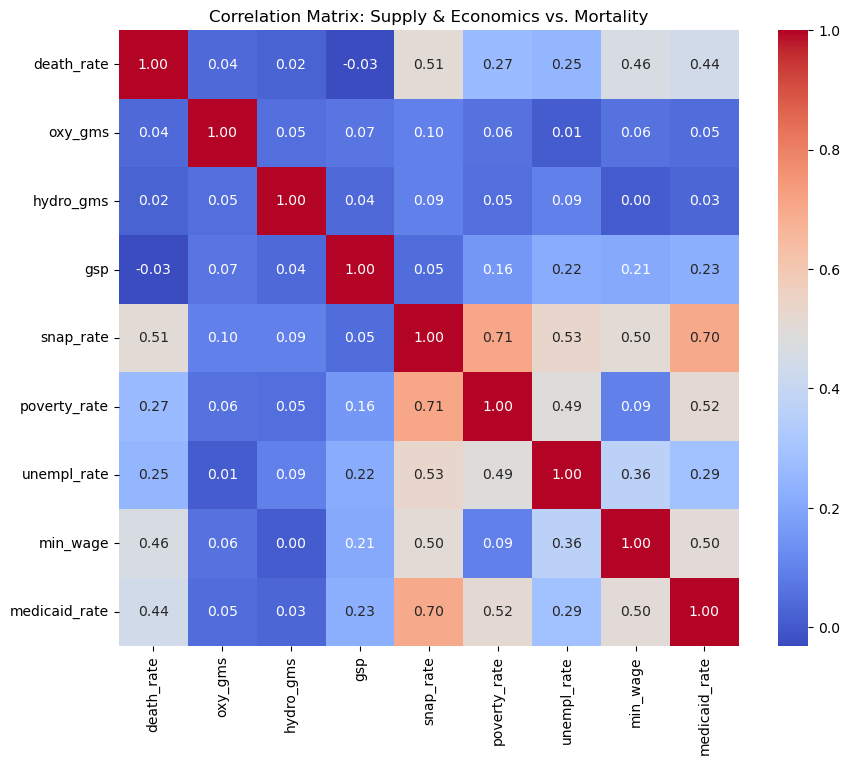

In [13]:
# Correlation
# Select variables for correlation
cols_to_corr = ['death_rate', 'oxy_gms', 'hydro_gms', 'gsp', 'snap_rate',
                'poverty_rate', 'unempl_rate', 'min_wage', 'medicaid_rate']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Supply & Economics vs. Mortality")
plt.show()

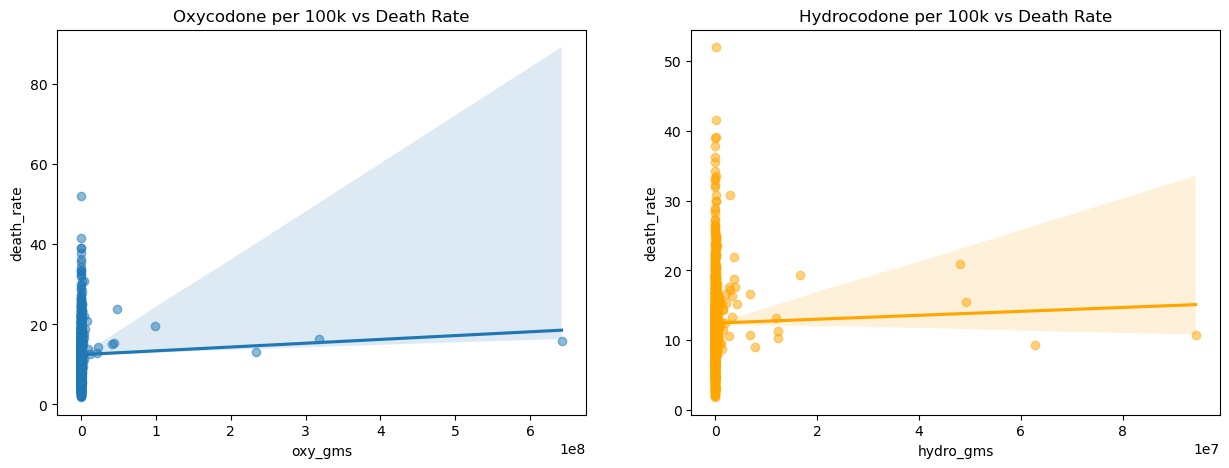

In [ ]:
# Scatter plots for oxy_gms and hydro_gms vs death_rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(data=df, x='oxy_gms', y='death_rate', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Oxycodone per 100k vs Death Rate')

sns.regplot(data=df, x='hydro_gms', y='death_rate', ax=ax2, scatter_kws={'alpha':0.5}, color='orange')
ax2.set_title('Hydrocodone per 100k vs Death Rate')

plt.show()

In [19]:
df.head()

,year,state,hydro_gms,oxy_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,aca_exp,gov_dem,death_rate,log_oxy,log_hydro
0,2000,AL,10664.777495,6724.566122,4.6,13.3,120132.9,5.15,0.088958,0.126888,0.0,1,4.4857,8.813671,9.274796
1,2001,AL,12065.615178,7317.474753,5.1,15.9,123035.3,5.15,0.092060,0.150865,0.0,1,4.8915,8.898157,9.398198
2,2002,AL,13477.895908,7919.213212,5.9,14.5,128117.4,5.15,0.099004,0.164526,0.0,1,4.7619,8.977173,9.508880
3,2003,AL,14846.170182,8496.910730,6.0,15.0,133969.3,5.15,0.104822,0.166062,0.0,0,4.4333,9.047576,9.605565
4,2004,AL,16186.581541,9060.957298,5.7,16.9,146886.7,5.15,0.109826,0.172655,0.0,0,6.3542,9.111840,9.692000


In [33]:
# 1. LOG FIRST: Handle the skewness/outliers
df['log_oxy'] = np.log1p(df['oxy_gms'])
df['log_hydro'] = np.log1p(df['hydro_gms'])

# 2. DEFINE GROUPS: Separate your features
# Continuous variables need scaling; Categorical/Binary (ACA, Gov) do not.
continuous_features = ['log_oxy', 'log_hydro', 'unempl_rate', 'poverty_rate', 'min_wage', 'medicaid_rate', 'gsp', 'snap_rate',
'death_rate']

# 3. SCALE SECOND: Put everything on a common -3 to +3 range
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [ ]:
formula = """death_rate ~ log_oxy + log_hydro + unempl_rate + 
             poverty_rate + min_wage + medicaid_rate + 
             aca_exp + C(gov_dem)"""

final_model = smf.ols(formula=formula, data=df).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             death_rate   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     65.28
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.40e-83
Time:                        19:05:28   Log-Likelihood:                -1000.8
No. Observations:                 850   AIC:                             2020.
Df Residuals:                     841   BIC:                             2062.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1098      0.038     

In [34]:
formula = """death_rate ~ log_oxy + log_hydro + unempl_rate + 
             poverty_rate + min_wage + medicaid_rate + 
             aca_exp + C(gov_dem) + C(state) + C(year)"""

final_model = smf.ols(formula=formula, data=df).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             death_rate   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     43.62
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          6.61e-227
Time:                        19:09:47   Log-Likelihood:                -513.40
No. Observations:                 850   AIC:                             1175.
Df Residuals:                     776   BIC:                             1526.
Df Model:                          73                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6813      0.154     

In [35]:
# 1. Sort to ensure chronological order for the shift
df = df.sort_values(['state', 'year'])

# 2. Create the 1-year lag for supply variables
df['oxy_lag1'] = df.groupby('state')['log_oxy'].shift(1)
df['hydro_lag1'] = df.groupby('state')['log_hydro'].shift(1)

# 3. Drop the first year (2000) for each state since it won't have a lag
# (This will drop about 50 rows)
df_lagged = df.dropna(subset=['oxy_lag1', 'hydro_lag1'])

In [36]:
# Updated formula using the lagged variables
formula_lag = """death_rate ~ oxy_lag1 + hydro_lag1 + unempl_rate + 
                 poverty_rate + min_wage + medicaid_rate + 
                 aca_exp + C(gov_dem) + C(state) + C(year)"""

fe_lag_model = smf.ols(formula=formula_lag, data=df_lagged).fit(cov_type='HC3')

print(fe_lag_model.summary().tables[1])
print(f"Lagged Model R-Squared: {fe_lag_model.rsquared:.4f}")

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.5454      0.178     -3.058      0.002      -0.895      -0.196
C(gov_dem)[T.1]    -0.0210      0.039     -0.533      0.594      -0.098       0.056
C(state)[T.AL]     -0.7275      0.198     -3.666      0.000      -1.116      -0.339
C(state)[T.AR]     -0.7456      0.233     -3.198      0.001      -1.202      -0.289
C(state)[T.AZ]      0.0416      0.200      0.208      0.835      -0.350       0.433
C(state)[T.CA]     -0.7674      0.233     -3.290      0.001      -1.224      -0.310
C(state)[T.CO]     -0.1341      0.191     -0.703      0.482      -0.508       0.240
C(state)[T.CT]     -0.1557      0.167     -0.930      0.352      -0.484       0.172
C(state)[T.DE]      0.0243      0.206      0.118      0.906      -0.379       0.428
C(state)[T.FL]     -0.0240      0.193     -0.125      0.901      -0.402     

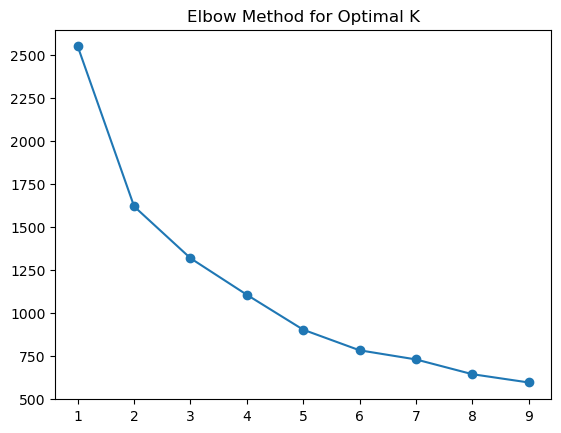

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select the features (use the scaled versions!)
cluster_features = ['log_oxy', 'poverty_rate', 'death_rate']
X = df[cluster_features]

# 2. Use the "Elbow Method" to find the right number of clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.show()

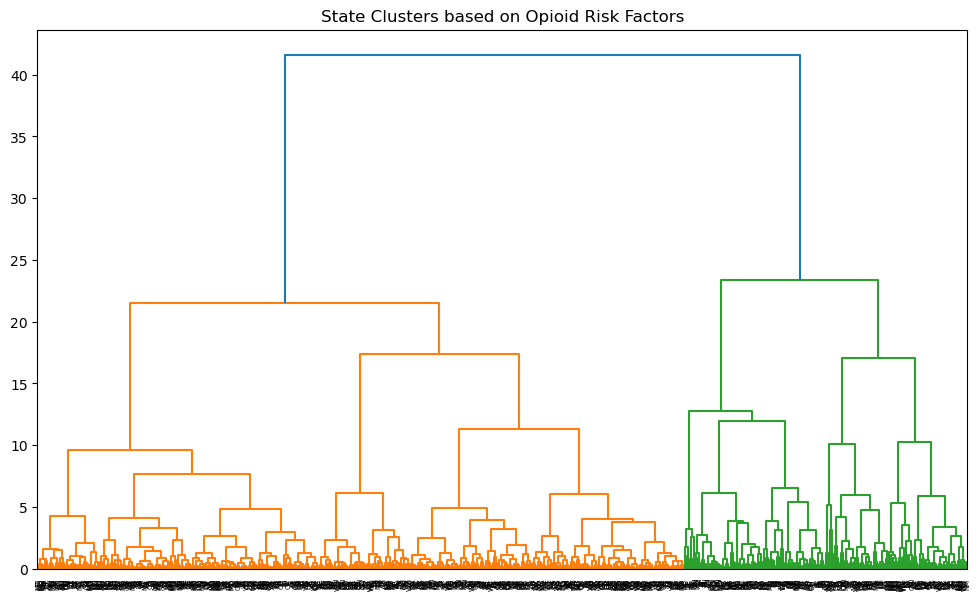

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use 'ward' linkage to minimize variance within clusters
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, labels=df['state'].values, leaf_rotation=90)
plt.title('State Clusters based on Opioid Risk Factors')
plt.show()

In [40]:
# 1. Fit the final model and grab the labels (not the distances)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_label'] = kmeans.fit_predict(X)  # Use fit_predict here

# 2. Now this will work
cluster_summary = df.groupby('cluster_label')[cluster_features].mean()
print(cluster_summary)

# 3. See which states are in the high-death cluster
high_risk_cluster = cluster_summary['death_rate'].idxmax()
print(f"States in High Risk Cluster: {df[df['cluster_label'] == high_risk_cluster]['state'].unique()}")

                log_oxy  poverty_rate  death_rate
cluster_label                                    
0             -0.462927     -0.610928   -0.467201
1              1.452444      0.234989    1.132634
2             -0.079527      1.150593    0.168502
States in High Risk Cluster: ['AL' 'CT' 'DE' 'FL' 'GA' 'IL' 'IN' 'KY' 'MA' 'MD' 'ME' 'MI' 'MO' 'MS'
 'NC' 'NH' 'NJ' 'NV' 'NY' 'OH' 'OK' 'PA' 'RI' 'TN' 'UT' 'VT' 'WI' 'WV'
 'WY']


In [44]:
import plotly.express as px

# 1. Create the 3D Scatter Plot
# Ensure you are using the unscaled original data for the plot labels!
fig = px.scatter_3d(df, x='oxy_gms', y='poverty_rate', z='death_rate',
                    color='cluster_label', # Color points by cluster
                    text='state', # Add state abbreviations to the points
                    title='3D State Risk Profiles',
                    labels={'oxy_gms': 'Oxy supply per 100k',
                            'poverty_rate': 'Poverty Rate (%)',
                            'death_rate': 'Opioid Death Rate'},
                    opacity=0.8)

# 2. Make the markers large and clear
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# 3. Use log scale on Oxy axis to handle the extreme outliers we saw earlier
fig.update_layout(scene=dict(xaxis=dict(type="log")))

fig.show()

In [45]:
import plotly.express as px

# 1. We need a clean mapping of Cluster Label (0, 1, 2) to names for the legend
cluster_map = {0: 'Low Risk/Stable', 1: 'Supply Epicenter (High Death)', 2: 'Economic Vulnerability'}
df['cluster_name'] = df['cluster_label'].map(cluster_map)

# 2. Create the Choropleth Map
fig = px.choropleth(df,
                    locations='state', # State column (must have AB codes like AL, KY, WV)
                    locationmode="USA-states", # Use built-in US map
                    color='cluster_name', # Fill colors by the cluster names we just created
                    color_discrete_sequence=["#2ca02c", "#d62728", "#ff7f0e"], # Green, Red, Orange
                    scope="usa", # Limit map to USA only
                    title='Map of State Risk Profiles (2000-2016)',
                    labels={'cluster_name': 'Risk Profile'})

# 3. Add state border lines for clarity
fig.update_layout(
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='rgb(255, 255, 255)'
    )
)

fig.show()